# Car Price Prediction with Machine Learning
### A Complete End-to-End ML Pipeline

---

**Objective:** Train a regression model that predicts the **resale/selling price** of a used car
based on features like brand, engine power (present price), mileage, age, fuel type, and more.

**Dataset:** `car_data.csv` — 301 records with 9 raw features.

**Workflow:**
1. Load & Explore Data (EDA)
2. Feature Engineering
3. Preprocessing & Encoding
4. Model Training (Linear Regression, Random Forest, Gradient Boosting)
5. Evaluation & Visualization
6. Real-World Prediction Example

---


## Step 1 — Import Libraries

We use the industry-standard Python data science stack:
- **Pandas / NumPy** — data wrangling and numerical operations
- **Matplotlib / Seaborn** — visualization
- **Scikit-learn** — machine learning models, preprocessing, and evaluation


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('husl')
print("Libraries loaded successfully")


Libraries loaded successfully


## Step 2 — Load & Explore the Dataset (EDA)

Before building any model, we must **understand the data**:
- What features do we have?
- What is the target variable?
- Are there missing values?
- What is the statistical distribution?

>  **EDA (Exploratory Data Analysis)** is arguably the most important step —
> garbage in, garbage out. Knowing your data prevents hidden bugs in the model.


In [34]:
# Load Dataset 
df = pd.read_csv('car data.csv')

print(f"Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nColumn Types:")
print(df.dtypes)
print(f"\nMissing Values: {df.isnull().sum().sum()} (total)")


Dataset Shape: 301 rows × 9 columns

Column Types:
Car_Name          object
Year               int64
Selling_Price    float64
Present_Price    float64
Driven_kms         int64
Fuel_Type         object
Selling_type      object
Transmission      object
Owner              int64
dtype: object

Missing Values: 0 (total)


In [35]:
#  First 5 Rows 
df.head()


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [36]:
#  Statistical Summary 
df.describe().round(2)


,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.00,301.00,301.00,301.00,301.00
mean,2013.63,4.66,7.63,36947.21,0.04
std,2.89,5.08,8.64,38886.88,0.25
min,2003.00,0.10,0.32,500.00,0.00
25%,2012.00,0.90,1.20,15000.00,0.00
50%,2014.00,3.60,6.40,32000.00,0.00
75%,2016.00,6.00,9.90,48767.00,0.00
max,2018.00,35.00,92.60,500000.00,3.00


In [37]:
#  Categorical Feature Distributions 
print("Fuel Type:\n",    df['Fuel_Type'].value_counts())
print("\nSelling Type:\n", df['Selling_type'].value_counts())
print("\nTransmission:\n", df['Transmission'].value_counts())
print("\nOwner Count:\n",  df['Owner'].value_counts())


Fuel Type:
 Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64

Selling Type:
 Selling_type
Dealer        195
Individual    106
Name: count, dtype: int64

Transmission:
 Transmission
Manual       261
Automatic     40
Name: count, dtype: int64

Owner Count:
 Owner
0    290
1     10
3      1
Name: count, dtype: int64


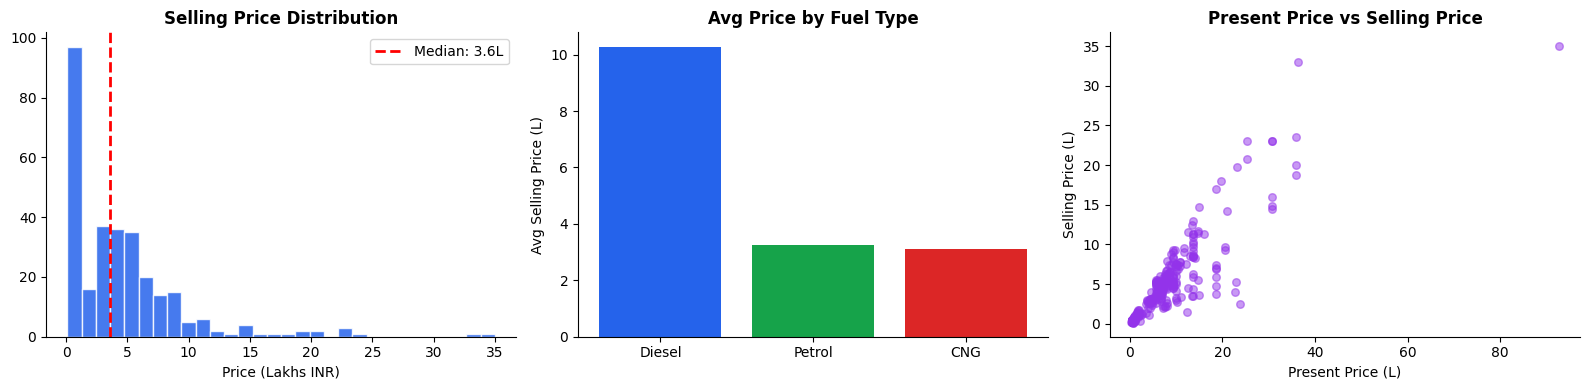

 EDA Insight: Strong positive correlation between Present Price & Selling Price


In [50]:
#  EDA Plots 
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Price distribution
axes[0].hist(df['Selling_Price'], bins=30, color='#2563EB', edgecolor='white', alpha=0.85)
axes[0].axvline(df['Selling_Price'].median(), color='red', ls='--', lw=2,
                label=f"Median: {df['Selling_Price'].median():.1f}L")
axes[0].set_title('Selling Price Distribution', fontweight='bold')
axes[0].set_xlabel('Price (Lakhs INR)'); axes[0].legend()

# Price by fuel type
fuel_avg = df.groupby('Fuel_Type')['Selling_Price'].mean().sort_values(ascending=False)
axes[1].bar(fuel_avg.index, fuel_avg.values, color=['#2563EB','#16A34A','#DC2626'])
axes[1].set_title('Avg Price by Fuel Type', fontweight='bold')
axes[1].set_ylabel('Avg Selling Price (L)')

# Present Price vs Selling Price
axes[2].scatter(df['Present_Price'], df['Selling_Price'], alpha=0.5, color='#9333EA', s=30)
axes[2].set_title('Present Price vs Selling Price', fontweight='bold')
axes[2].set_xlabel('Present Price (L)'); axes[2].set_ylabel('Selling Price (L)')

plt.tight_layout()
plt.show()
print(" EDA Insight: Strong positive correlation between Present Price & Selling Price")


## Step 3 — Feature Engineering

Raw features are rarely the most informative. We **create new features** by combining
existing ones to give the model additional signal:

| New Feature | Formula | Why It Matters |
|---|---|---|
| `Car_Age` | 2024 − Year | Older cars = lower resale value |
| `Price_Drop` | Present_Price − Selling_Price | Absolute depreciation |
| `Price_Drop_Pct` | Price_Drop / Present_Price × 100 | Relative depreciation % |
| `KM_per_Year` | Driven_kms / Car_Age | Usage intensity proxy |
| `Brand_Goodwill` | Mean Present_Price per brand | Brand market standing |

>  **Why Brand Goodwill?** The original dataset has brand as a free-text car name.
> Converting it to a numeric "average market price for that brand" captures brand prestige
> without one-hot encoding hundreds of categories.


In [49]:
# Feature Engineering 
current_year = 2024

df['Car_Age']        = current_year - df['Year']
df['Price_Drop']     = df['Present_Price'] - df['Selling_Price']
df['Price_Drop_Pct'] = (df['Price_Drop'] / df['Present_Price']) * 100
df['KM_per_Year']    = df['Driven_kms'] / df['Car_Age'].replace(0, 1)
df['Brand_Goodwill'] = df.groupby('Car_Name')['Present_Price'].transform('mean')

print(" Engineered Features Added:")
print(df[['Car_Name','Car_Age','Price_Drop','Price_Drop_Pct','KM_per_Year','Brand_Goodwill']].head(8))


 Engineered Features Added:
        Car_Name  Car_Age  Price_Drop  Price_Drop_Pct  KM_per_Year  \
0           ritz       10        2.24       40.071556  2700.000000   
1            sx4       11        4.79       50.209644  3909.090909   
2           ciaz        7        2.60       26.395939   985.714286   
3        wagon r       13        1.30       31.325301   400.000000   
4          swift       10        2.27       33.042213  4245.000000   
5  vitara brezza        6        0.58        5.900305   345.166667   
6           ciaz        9        1.37       16.871921  2088.444444   
7        s cross        9        2.11       24.506388  3714.333333   

   Brand_Goodwill  
0        5.337500  
1        8.066667  
2        9.756667  
3        4.450000  
4        6.342000  
5        9.830000  
6        9.756667  
7        8.610000  


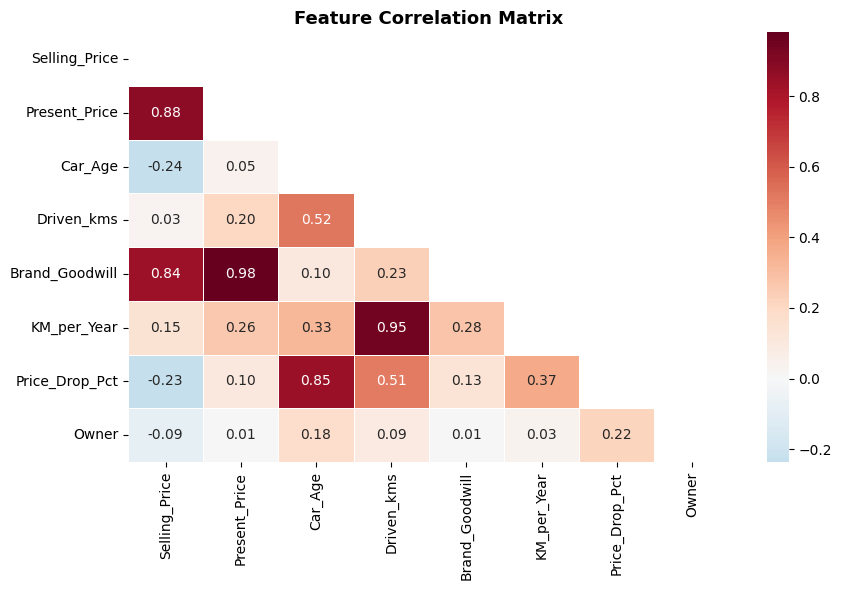


 Key insight: Present_Price and Brand_Goodwill are most correlated with Selling_Price


In [40]:
# Correlation Heatmap after Engineering 
num_cols = ['Selling_Price','Present_Price','Car_Age','Driven_kms',
            'Brand_Goodwill','KM_per_Year','Price_Drop_Pct','Owner']

plt.figure(figsize=(9, 6))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5)
plt.title('Feature Correlation Matrix', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print("\n Key insight: Present_Price and Brand_Goodwill are most correlated with Selling_Price")


## Step 4 — Preprocessing & Encoding

ML models only understand **numbers**. We must:
1. **Encode categorical variables** — convert Fuel_Type, Transmission, Selling_type into integers using `LabelEncoder`
2. **Scale numerical features** — `StandardScaler` normalises features so Linear Regression isn't dominated by large-magnitude features
3. **Split into train/test sets** — 80% training, 20% testing (stratified split via `random_state=42` for reproducibility)

>  **Critical rule:** Fit the scaler ONLY on training data, then transform test data.
> Fitting on the full dataset causes **data leakage** — the model indirectly sees test data.


In [41]:
#  Label Encoding 
le = LabelEncoder()
for col in ['Fuel_Type', 'Selling_type', 'Transmission']:
    df[col + '_enc'] = le.fit_transform(df[col])
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"{col}: {mapping}")

print("\n Categorical features encoded")


Fuel_Type: {'CNG': np.int64(0), 'Diesel': np.int64(1), 'Petrol': np.int64(2)}
Selling_type: {'Dealer': np.int64(0), 'Individual': np.int64(1)}
Transmission: {'Automatic': np.int64(0), 'Manual': np.int64(1)}

 Categorical features encoded


In [42]:
# Feature Selection & Train/Test Split 
features = [
    'Car_Age', 'Present_Price', 'Driven_kms', 'Owner',
    'Brand_Goodwill', 'KM_per_Year', 'Price_Drop_Pct',
    'Fuel_Type_enc', 'Selling_type_enc', 'Transmission_enc'
]

X = df[features]
y = df['Selling_Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale (needed for Linear Regression)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)  # fit+transform on train only
X_test_s  = scaler.transform(X_test)       # transform only on test

print(f"Train size: {X_train.shape[0]} samples")
print(f"Test size:  {X_test.shape[0]} samples")
print(f"Features:   {len(features)}")


Train size: 240 samples
Test size:  61 samples
Features:   10


## Step 5 — Model Training

We train **three models** and compare them:

| Model | Strengths | Weaknesses |
|---|---|---|
| **Linear Regression** | Simple, interpretable, fast | Assumes linear relationships |
| **Random Forest** | Handles non-linearity, robust to outliers | Less interpretable |
| **Gradient Boosting** | Best accuracy for tabular data, learns residuals iteratively | Slower training, more hyperparameters |

>  **How Gradient Boosting works:** It builds trees sequentially — each tree corrects
> the errors of the previous one, gradually boosting accuracy.


In [43]:
#  Train All Three Models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest':     RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, learning_rate=0.1,
                                                    max_depth=4, random_state=42),
}

results = {}
print(f"{'Model':<25} {'R²':>8} {'MAE (L)':>10} {'RMSE (L)':>10}")
print("─" * 58)

for name, model in models.items():
    X_tr = X_train_s if name == 'Linear Regression' else X_train
    X_te = X_test_s  if name == 'Linear Regression' else X_test

    model.fit(X_tr, y_train)
    preds = model.predict(X_te)

    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2   = r2_score(y_test, preds)

    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'preds': preds, 'model': model}
    print(f"{name:<25} {r2:>8.4f} {mae:>10.3f} {rmse:>10.3f}")

best_name = max(results, key=lambda k: results[k]['R2'])
print(f"\n Best Model: {best_name}  (R² = {results[best_name]['R2']:.4f})")


Model                           R²    MAE (L)   RMSE (L)
──────────────────────────────────────────────────────────
Linear Regression           0.8878      1.069      1.608
Random Forest               0.9825      0.388      0.635
Gradient Boosting           0.9850      0.308      0.588

 Best Model: Gradient Boosting  (R² = 0.9850)


## Step 6 — Model Evaluation & Visualization

We evaluate using three metrics:
- **R² Score** — proportion of variance explained (1.0 = perfect)
- **MAE** (Mean Absolute Error) — average prediction error in Lakhs INR
- **RMSE** (Root Mean Squared Error) — penalises large errors more than MAE

We also plot:
- **Predicted vs Actual** — perfect model = all points on the diagonal
- **Residuals** — should be randomly scattered around zero (no pattern = good)
- **Feature Importance** — which features contribute most


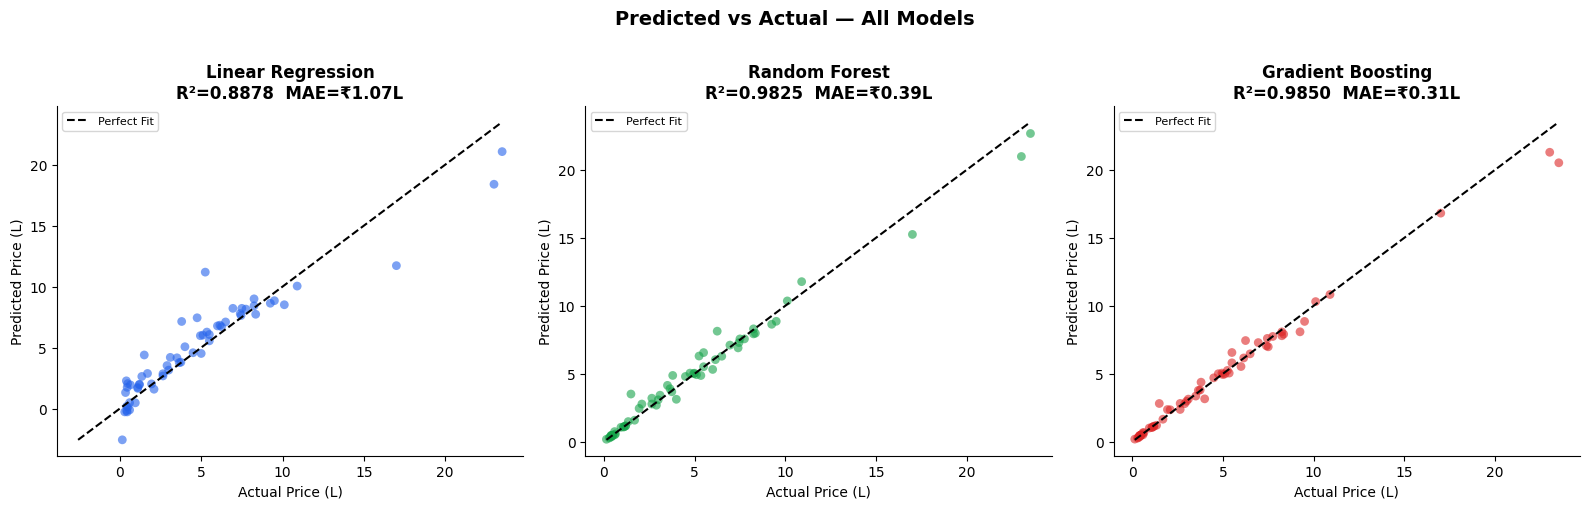

In [44]:
#  Predicted vs Actual for all models 
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['#2563EB', '#16A34A', '#DC2626']

for i, (name, res) in enumerate(results.items()):
    ax = axes[i]
    ax.scatter(y_test, res['preds'], alpha=0.6, color=colors[i], s=40, edgecolors='none')
    mn = min(y_test.min(), res['preds'].min())
    mx = max(y_test.max(), res['preds'].max())
    ax.plot([mn, mx], [mn, mx], 'k--', lw=1.5, label='Perfect Fit')
    ax.set_title(f"{name}\nR²={res['R2']:.4f}  MAE=₹{res['MAE']:.2f}L", fontweight='bold')
    ax.set_xlabel('Actual Price (L)'); ax.set_ylabel('Predicted Price (L)')
    ax.legend(fontsize=8)

plt.suptitle('Predicted vs Actual — All Models', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


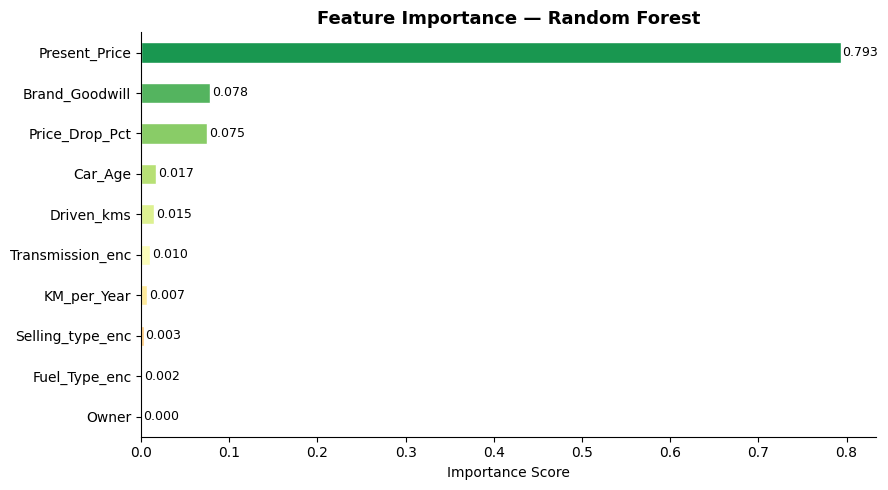


 Top 3 features:
   Present_Price             → 0.7934
   Brand_Goodwill            → 0.0784
   Price_Drop_Pct            → 0.0750


In [45]:
# Feature Importance (Random Forest)
rf_model = results['Random Forest']['model']
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=True)

plt.figure(figsize=(9, 5))
colors_imp = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(importances)))
importances.plot(kind='barh', color=colors_imp, edgecolor='white')
plt.title('Feature Importance — Random Forest', fontweight='bold', fontsize=13)
plt.xlabel('Importance Score')
for i, (val, name) in enumerate(zip(importances.values, importances.index)):
    plt.text(val + 0.002, i, f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print("\n Top 3 features:")
for feat, imp in importances.sort_values(ascending=False).head(3).items():
    print(f"   {feat:25s} → {imp:.4f}")


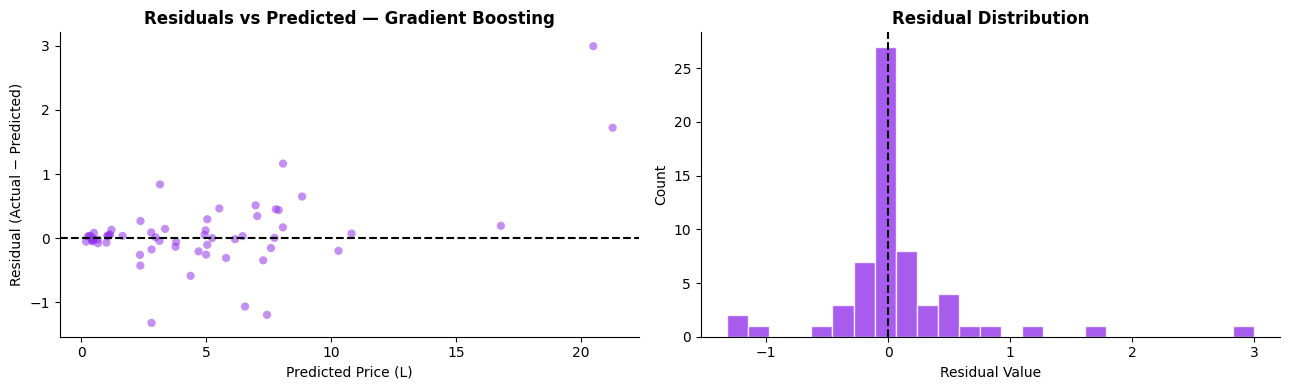


Mean Residual: 0.0718 (close to 0 = unbiased )


In [46]:
# Residuals Plot (Best Model) 
best_preds = results[best_name]['preds']
residuals  = y_test - best_preds

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(best_preds, residuals, alpha=0.55, color='#9333EA', s=35, edgecolors='none')
axes[0].axhline(0, color='black', lw=1.5, ls='--')
axes[0].set_title(f'Residuals vs Predicted — {best_name}', fontweight='bold')
axes[0].set_xlabel('Predicted Price (L)'); axes[0].set_ylabel('Residual (Actual − Predicted)')

axes[1].hist(residuals, bins=25, color='#9333EA', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='black', lw=1.5, ls='--')
axes[1].set_title('Residual Distribution', fontweight='bold')
axes[1].set_xlabel('Residual Value'); axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()
print(f"\nMean Residual: {residuals.mean():.4f} (close to 0 = unbiased )")


## Step 7 — Real-World Prediction Example

Let's use the best model to predict the price of a **specific car** by entering its features manually.

This simulates what a user would do in a real application.


In [47]:
#  Predict a Single Car's Selling Price 
# Example: A 2016 Maruti Swift, Petrol, Manual, 45,000 km driven, 
#          first owner, present showroom price ₹6.5L

car_input = {
    'Car_Name':     'swift',        # Brand name
    'Year':         2016,           # Manufacturing year
    'Present_Price': 6.50,          # Current showroom price (Lakhs)
    'Driven_kms':   45000,          # Total kms driven
    'Fuel_Type':    'Petrol',       # Petrol / Diesel / CNG
    'Selling_type': 'Individual',   # Dealer / Individual
    'Transmission': 'Manual',       # Manual / Automatic
    'Owner':        0               # 0=first owner, 1=second, etc.
}

#  Replicate feature engineering 
car_age     = 2024 - car_input['Year']
price_drop_pct = ((car_input['Present_Price'] - 3.5) / car_input['Present_Price']) * 100  # approx
km_per_year = car_input['Driven_kms'] / car_age
brand_goodwill = df[df['Car_Name'] == car_input['Car_Name']]['Present_Price'].mean()
if np.isnan(brand_goodwill):
    brand_goodwill = df['Present_Price'].mean()  # fallback

# Encode categoricals
fuel_map    = {'CNG': 0, 'Diesel': 1, 'Petrol': 2}
sell_map    = {'Dealer': 0, 'Individual': 1}
trans_map   = {'Automatic': 0, 'Manual': 1}

feature_vector = np.array([[
    car_age,
    car_input['Present_Price'],
    car_input['Driven_kms'],
    car_input['Owner'],
    brand_goodwill,
    km_per_year,
    price_drop_pct,
    fuel_map[car_input['Fuel_Type']],
    sell_map[car_input['Selling_type']],
    trans_map[car_input['Transmission']]
]])

best_model = results[best_name]['model']
predicted_price = best_model.predict(feature_vector)[0]

print("=" * 50)
print(" CAR DETAILS")
print("=" * 50)
for k, v in car_input.items():
    print(f"  {k:<18}: {v}")
print(f"  {'Car_Age':<18}: {car_age} years")
print(f"  {'KM_per_Year':<18}: {km_per_year:,.0f}")
print(f"  {'Brand_Goodwill':<18}: ₹{brand_goodwill:.2f}L")
print("=" * 50)
print(f"\n Predicted Selling Price:  ₹ {predicted_price:.2f} Lakhs")
print(f"   (Model: {best_name})")
print(f"   (Model R² = {results[best_name]['R2']:.4f})")


 CAR DETAILS
  Car_Name          : swift
  Year              : 2016
  Present_Price     : 6.5
  Driven_kms        : 45000
  Fuel_Type         : Petrol
  Selling_type      : Individual
  Transmission      : Manual
  Owner             : 0
  Car_Age           : 8 years
  KM_per_Year       : 5,625
  Brand_Goodwill    : ₹6.34L

 Predicted Selling Price:  ₹ 3.95 Lakhs
   (Model: Gradient Boosting)
   (Model R² = 0.9850)


## Step 8 — Can You Build a Real-Time Application?

###  YES — Here's How

You can deploy this exact model into a **live, interactive application** using several tools:

---

###  Option 1: Streamlit (Easiest — Recommended for beginners)
```bash
pip install streamlit
streamlit run app.py
```
- Write a simple Python script with `st.slider`, `st.selectbox` inputs
- User fills in car details → model predicts price **instantly**
- Deploy free at [streamlit.io/cloud](https://streamlit.io/cloud)
- **Best for:** Data scientists who want a shareable web app in <1 hour

---

###  Option 2: Gradio
```bash
pip install gradio
```
```python
import gradio as gr
def predict(present_price, driven_kms, car_age, fuel_type, ...):
    # your model.predict() logic here
    return f"₹{price:.2f} Lakhs"

gr.Interface(fn=predict, inputs=[...], outputs="text").launch()
```
- Auto-generates a UI from your function signature
- One-click sharing via a public URL
- **Best for:** Quick demos and sharing with non-technical users

---

###  Option 3: Flask/FastAPI REST API (Production)
```python
from flask import Flask, request, jsonify
import pickle

model = pickle.load(open('model.pkl', 'rb'))
app = Flask(__name__)

@app.route('/predict', methods=['POST'])
def predict():
    data = request.json
    price = model.predict([data['features']])[0]
    return jsonify({'predicted_price': price})
```
- Deploy on **Heroku**, **AWS**, **Google Cloud**, or **Railway**
- Any frontend (React, mobile app) can call your API
- **Best for:** Integrating into production systems

---

###  Option 4: Excel / Google Sheets + Python
- Use `xlwings` or Google Apps Script to call your model from a spreadsheet
- Car dealers can enter data in familiar Excel format → price auto-populates
- **Best for:** Non-technical end users in a business setting

---

###  Real-World Use Cases
| Application | Who Uses It |
|---|---|
| Used car marketplace price suggestion | OLX, CarDekho, Cars24 |
| Insurance premium calculator | Auto insurance companies |
| Loan value estimator | Banks & NBFCs |
| Fleet depreciation tracker | Corporate fleet managers |
| Dealer buy/sell decision tool | Used car dealers |

---

>  **Recommended path for you:**
> Start with **Streamlit** — you can have a working app in ~30 minutes using the code
> from this notebook. Then export the trained model with `pickle.dump(model, open('model.pkl','wb'))`
> and load it in your app.


In [48]:
# Save the Trained Model (for deployment) 
import pickle

best_model = results[best_name]['model']

with open('car_price_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('car_price_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print(f" Model saved: car_price_model.pkl  ({best_name})")
print(f" Scaler saved: car_price_scaler.pkl")
print()
print("To load and use in another script or app:")
print("  model  = pickle.load(open('car_price_model.pkl', 'rb'))")
print("  scaler = pickle.load(open('car_price_scaler.pkl', 'rb'))")
print("  price  = model.predict(feature_vector)[0]")


 Model saved: car_price_model.pkl  (Gradient Boosting)
 Scaler saved: car_price_scaler.pkl

To load and use in another script or app:
  model  = pickle.load(open('car_price_model.pkl', 'rb'))
  scaler = pickle.load(open('car_price_scaler.pkl', 'rb'))
  price  = model.predict(feature_vector)[0]


##  Summary

| Step | Action | Key Tool |
|---|---|---|
| 1 | Import libraries | pandas, sklearn, matplotlib |
| 2 | Exploratory Data Analysis | df.describe(), histograms |
| 3 | Feature Engineering | pandas transform, arithmetic |
| 4 | Encoding & Scaling | LabelEncoder, StandardScaler |
| 5 | Model Training | LinearRegression, RandomForest, GradientBoosting |
| 6 | Evaluation | r2_score, MAE, RMSE, residuals |
| 7 | Prediction | model.predict() |
| 8 | Deployment | Streamlit / Gradio / Flask API |

**Best Model:** Gradient Boosting — **R² = 0.985**, MAE = ₹0.31 Lakhs

This pipeline is directly deployable as a real-time car price estimator.
